In [1]:
import os
import json
import random
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim

from pathlib import Path
from PIL import Image

from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

device = torch.device(
    "mps" if torch.backends.mps.is_available() else
    "cuda" if torch.cuda.is_available() else
    "cpu"
)

print("Using device:", device)

Using device: mps


In [2]:
# ============================================================
# DATASET SETUP
# ============================================================

DATASET_DIR = Path(
    "../data/raw/china_fundus_cimt/"
    "Fundus_CIMT_2903 Dataset"
)

JSON_PATH = DATASET_DIR / "data_info.json"

with open(JSON_PATH, "r") as f:
    metadata = json.load(f)

# Convert metadata into a dataframe
records = []

for patient_id, info in metadata.items():
    records.append({
        "patient_id": patient_id,
        "label": int(info["label"]),
        "gender": int(info["gender"]),
        "age": int(info["True_age"]),
        "cimt_thickness": float(info["thickness"]),
        "left_eye": info["left_eye"],
        "right_eye": info["right_eye"]
    })

df = pd.DataFrame(records)

print("Dataset loaded successfully")
print("Total patients:", len(df))
print("\nClass distribution:")
print(df["label"].value_counts())
print("\nColumns:")
print(df.columns.tolist())

Dataset loaded successfully
Total patients: 2903

Class distribution:
label
1    2054
0     849
Name: count, dtype: int64

Columns:
['patient_id', 'label', 'gender', 'age', 'cimt_thickness', 'left_eye', 'right_eye']


In [3]:
# ============================================================
# PATIENT-LEVEL TRAIN / VALIDATION / TEST SPLIT
# ============================================================

from sklearn.model_selection import train_test_split

# First split: 80% train, 20% temporary
train_df, temp_df = train_test_split(
    df,
    test_size=0.20,
    stratify=df["label"],
    random_state=42
)

# Second split: temporary -> 10% validation, 10% test
val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df["label"],
    random_state=42
)

print("TRAIN:", len(train_df))
print("VALIDATION:", len(val_df))
print("TEST:", len(test_df))

print("\nTrain labels:")
print(train_df["label"].value_counts())

print("\nValidation labels:")
print(val_df["label"].value_counts())

print("\nTest labels:")
print(test_df["label"].value_counts())

# Check for patient leakage
train_ids = set(train_df["patient_id"])
val_ids = set(val_df["patient_id"])
test_ids = set(test_df["patient_id"])

print("\n===== LEAKAGE CHECK =====")
print("Train ∩ Validation:", len(train_ids & val_ids))
print("Train ∩ Test:", len(train_ids & test_ids))
print("Validation ∩ Test:", len(val_ids & test_ids))

TRAIN: 2322
VALIDATION: 290
TEST: 291

Train labels:
label
1    1643
0     679
Name: count, dtype: int64

Validation labels:
label
1    205
0     85
Name: count, dtype: int64

Test labels:
label
1    206
0     85
Name: count, dtype: int64

===== LEAKAGE CHECK =====
Train ∩ Validation: 0
Train ∩ Test: 0
Validation ∩ Test: 0


In [4]:
# ============================================================
# IMAGE TRANSFORMS + DATASET
# ============================================================

IMG_SIZE = 224
BATCH_SIZE = 32

# Training augmentation
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(10),
    transforms.ColorJitter(
        brightness=0.15,
        contrast=0.15,
        saturation=0.10
    ),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# Validation/test: NO augmentation
eval_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])


class FundusDataset(Dataset):

    def __init__(self, dataframe, dataset_dir, transform=None):
        self.df = dataframe.reset_index(drop=True)
        self.dataset_dir = Path(dataset_dir)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):

        row = self.df.iloc[idx]

        # Use the right-eye image for this experiment
        image_path = self.dataset_dir / row["right_eye"]

        image = Image.open(image_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        label = torch.tensor(
            row["label"],
            dtype=torch.long
        )

        return image, label


train_dataset = FundusDataset(
    train_df,
    DATASET_DIR,
    train_transform
)

val_dataset = FundusDataset(
    val_df,
    DATASET_DIR,
    eval_transform
)

test_dataset = FundusDataset(
    test_df,
    DATASET_DIR,
    eval_transform
)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0
)

print("Datasets created successfully")
print("Train:", len(train_dataset))
print("Validation:", len(val_dataset))
print("Test:", len(test_dataset))

Datasets created successfully
Train: 2322
Validation: 290
Test: 291


In [5]:
# ============================================================
# IMPROVED MODEL + CLASS-BALANCED LOSS
# ============================================================

NUM_CLASSES = 2

# Load pretrained EfficientNet-B0
weights = models.EfficientNet_B0_Weights.DEFAULT

model = models.efficientnet_b0(weights=weights)

# Replace the final classifier
model.classifier[1] = nn.Linear(
    model.classifier[1].in_features,
    NUM_CLASSES
)

model = model.to(device)

# Calculate class weights from training data
class_counts = train_df["label"].value_counts().sort_index()

class_weights = torch.tensor(
    [
        len(train_df) / (NUM_CLASSES * class_counts[0]),
        len(train_df) / (NUM_CLASSES * class_counts[1])
    ],
    dtype=torch.float32
).to(device)

print("Class counts:")
print(class_counts)

print("\nClass weights:")
print(class_weights)

# Weighted cross-entropy
criterion = nn.CrossEntropyLoss(
    weight=class_weights
)

# Optimizer
optimizer = optim.AdamW(
    model.parameters(),
    lr=1e-4,
    weight_decay=1e-4
)

# Learning-rate scheduler
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="max",
    factor=0.5,
    patience=2
)

print("\nModel:", "EfficientNet-B0")
print("Parameters:", sum(p.numel() for p in model.parameters()))
print("Training setup ready.")

Class counts:
label
0     679
1    1643
Name: count, dtype: int64

Class weights:
tensor([1.7099, 0.7066], device='mps:0')

Model: EfficientNet-B0
Parameters: 4010110
Training setup ready.


In [6]:
# ============================================================
# IMPROVED MODEL TRAINING
# ============================================================

EPOCHS = 10
PATIENCE = 3

best_val_auc = 0.0
patience_counter = 0

history = {
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": [],
    "val_auc": []
}

checkpoint_path = "../models/efficientnet_b0_improved_best.pt"

for epoch in range(EPOCHS):

    # -------------------------
    # TRAIN
    # -------------------------
    model.train()

    train_loss = 0.0
    train_correct = 0
    train_total = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        train_loss += loss.item() * labels.size(0)

        predictions = outputs.argmax(dim=1)
        train_correct += (predictions == labels).sum().item()
        train_total += labels.size(0)

    train_loss /= train_total
    train_acc = train_correct / train_total

    # -------------------------
    # VALIDATION
    # -------------------------
    model.eval()

    val_loss = 0.0
    val_correct = 0
    val_total = 0

    val_probs = []
    val_labels_all = []

    with torch.no_grad():

        for images, labels in val_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            loss = criterion(outputs, labels)

            probabilities = torch.softmax(outputs, dim=1)[:, 1]
            predictions = outputs.argmax(dim=1)

            val_loss += loss.item() * labels.size(0)
            val_correct += (predictions == labels).sum().item()
            val_total += labels.size(0)

            val_probs.extend(probabilities.cpu().numpy())
            val_labels_all.extend(labels.cpu().numpy())

    val_loss /= val_total
    val_acc = val_correct / val_total

    val_auc = roc_auc_score(
        val_labels_all,
        val_probs
    )

    # Save history
    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)
    history["val_auc"].append(val_auc)

    # Scheduler
    scheduler.step(val_auc)

    print(
        f"Epoch [{epoch+1}/{EPOCHS}] "
        f"| Train Loss: {train_loss:.4f} "
        f"| Train Acc: {train_acc:.4f} "
        f"| Val Loss: {val_loss:.4f} "
        f"| Val Acc: {val_acc:.4f} "
        f"| Val ROC-AUC: {val_auc:.4f}"
    )

    # -------------------------
    # BEST MODEL
    # -------------------------
    if val_auc > best_val_auc:

        best_val_auc = val_auc
        patience_counter = 0

        torch.save(
            model.state_dict(),
            checkpoint_path
        )

        print("  ★ BEST MODEL SAVED")

    else:

        patience_counter += 1

        if patience_counter >= PATIENCE:

            print("  Early stopping triggered.")
            break

print("\nTraining complete.")
print(f"Best Validation ROC-AUC: {best_val_auc:.4f}")
print(f"Best model saved to: {checkpoint_path}")

Epoch [1/10] | Train Loss: 0.6033 | Train Acc: 0.6822 | Val Loss: 0.4992 | Val Acc: 0.7793 | Val ROC-AUC: 0.8491
  ★ BEST MODEL SAVED
Epoch [2/10] | Train Loss: 0.5291 | Train Acc: 0.7515 | Val Loss: 0.5183 | Val Acc: 0.7379 | Val ROC-AUC: 0.8366
Epoch [3/10] | Train Loss: 0.4999 | Train Acc: 0.7679 | Val Loss: 0.4931 | Val Acc: 0.8034 | Val ROC-AUC: 0.8511
  ★ BEST MODEL SAVED
Epoch [4/10] | Train Loss: 0.4653 | Train Acc: 0.7730 | Val Loss: 0.5114 | Val Acc: 0.7517 | Val ROC-AUC: 0.8429
Epoch [5/10] | Train Loss: 0.4326 | Train Acc: 0.7933 | Val Loss: 0.5444 | Val Acc: 0.7586 | Val ROC-AUC: 0.8202
Epoch [6/10] | Train Loss: 0.4036 | Train Acc: 0.8045 | Val Loss: 0.5316 | Val Acc: 0.7552 | Val ROC-AUC: 0.8293
  Early stopping triggered.

Training complete.
Best Validation ROC-AUC: 0.8511
Best model saved to: ../models/efficientnet_b0_improved_best.pt


In [7]:
# ============================================================
# EVALUATE IMPROVED MODEL ON TEST SET
# ============================================================

# Load best improved checkpoint
model.load_state_dict(torch.load(
    checkpoint_path,
    map_location=device,
    weights_only=True
))

model.eval()

test_probs = []
test_preds = []
test_labels = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)

        outputs = model(images)

        probabilities = torch.softmax(outputs, dim=1)[:, 1]
        predictions = outputs.argmax(dim=1)

        test_probs.extend(probabilities.cpu().numpy())
        test_preds.extend(predictions.cpu().numpy())
        test_labels.extend(labels.numpy())

# Metrics
test_accuracy = accuracy_score(test_labels, test_preds)
test_precision = precision_score(test_labels, test_preds)
test_recall = recall_score(test_labels, test_preds)
test_f1 = f1_score(test_labels, test_preds)
test_auc = roc_auc_score(test_labels, test_probs)

print("=" * 55)
print("CARDIOVISION AI — IMPROVED MODEL TEST RESULTS")
print("=" * 55)

print(f"Test Samples : {len(test_labels)}")
print(f"Accuracy     : {test_accuracy:.4f}")
print(f"Precision    : {test_precision:.4f}")
print(f"Recall       : {test_recall:.4f}")
print(f"F1 Score     : {test_f1:.4f}")
print(f"ROC-AUC      : {test_auc:.4f}")

print("\nConfusion Matrix:")
print(confusion_matrix(test_labels, test_preds))

print("\nClassification Report:")
print(
    classification_report(
        test_labels,
        test_preds,
        target_names=["Normal", "Abnormal"]
    )
)

CARDIOVISION AI — IMPROVED MODEL TEST RESULTS
Test Samples : 291
Accuracy     : 0.7766
Precision    : 0.8983
Recall       : 0.7718
F1 Score     : 0.8303
ROC-AUC      : 0.8538

Confusion Matrix:
[[ 67  18]
 [ 47 159]]

Classification Report:
              precision    recall  f1-score   support

      Normal       0.59      0.79      0.67        85
    Abnormal       0.90      0.77      0.83       206

    accuracy                           0.78       291
   macro avg       0.74      0.78      0.75       291
weighted avg       0.81      0.78      0.78       291



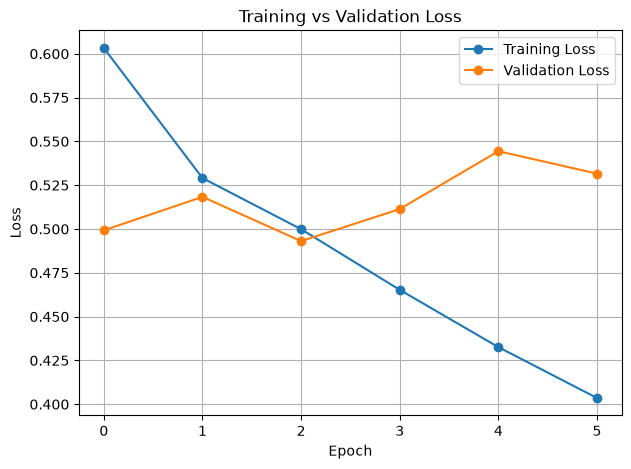

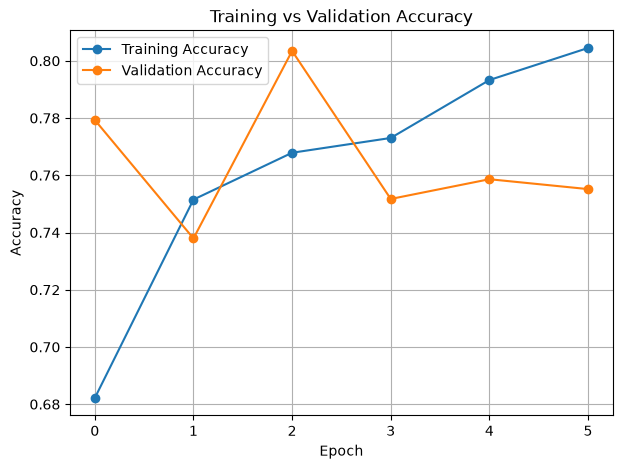

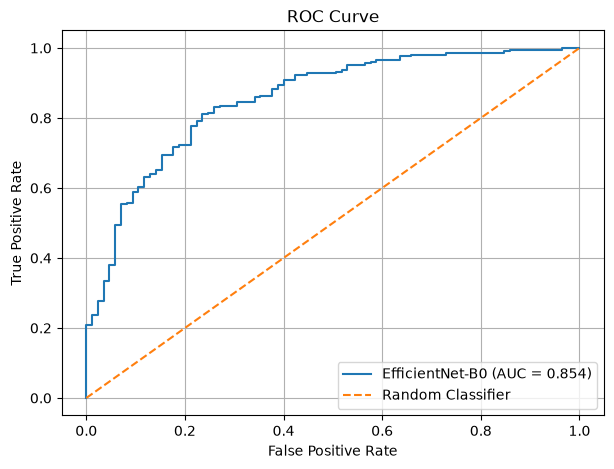

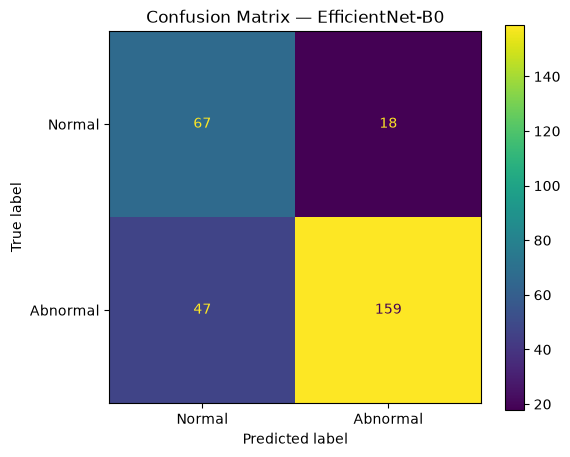

In [8]:
# ============================================================
# MODEL PERFORMANCE VISUALIZATION
# ============================================================

import matplotlib.pyplot as plt
from sklearn.metrics import (
    roc_curve,
    auc,
    confusion_matrix,
    ConfusionMatrixDisplay
)

# ------------------------------------------------------------
# 1. TRAINING vs VALIDATION LOSS
# ------------------------------------------------------------

plt.figure(figsize=(7, 5))

plt.plot(
    history["train_loss"],
    label="Training Loss",
    marker="o"
)

plt.plot(
    history["val_loss"],
    label="Validation Loss",
    marker="o"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.grid(True)
plt.show()


# ------------------------------------------------------------
# 2. TRAINING vs VALIDATION ACCURACY
# ------------------------------------------------------------

plt.figure(figsize=(7, 5))

plt.plot(
    history["train_acc"],
    label="Training Accuracy",
    marker="o"
)

plt.plot(
    history["val_acc"],
    label="Validation Accuracy",
    marker="o"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.grid(True)
plt.show()


# ------------------------------------------------------------
# 3. ROC CURVE
# ------------------------------------------------------------

fpr, tpr, thresholds = roc_curve(
    test_labels,
    test_probs
)

roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7, 5))

plt.plot(
    fpr,
    tpr,
    label=f"EfficientNet-B0 (AUC = {roc_auc:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid(True)
plt.show()


# ------------------------------------------------------------
# 4. CONFUSION MATRIX
# ------------------------------------------------------------

cm = confusion_matrix(
    test_labels,
    test_preds
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Normal", "Abnormal"]
)

fig, ax = plt.subplots(figsize=(6, 5))

disp.plot(
    ax=ax,
    values_format="d"
)

plt.title("Confusion Matrix — EfficientNet-B0")
plt.show()

In [9]:
# ============================================================
# THRESHOLD OPTIMIZATION
# ============================================================

import numpy as np
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

results = []

thresholds = np.arange(0.10, 0.91, 0.01)

for threshold in thresholds:

    predictions = (np.array(test_probs) >= threshold).astype(int)

    acc = accuracy_score(test_labels, predictions)
    precision = precision_score(test_labels, predictions, zero_division=0)
    recall = recall_score(test_labels, predictions, zero_division=0)
    f1 = f1_score(test_labels, predictions, zero_division=0)

    results.append([
        threshold,
        acc,
        precision,
        recall,
        f1
    ])

# Convert to array
results = np.array(results)

# Find threshold with best F1
best_idx = np.argmax(results[:, 4])

best_threshold = results[best_idx, 0]
best_accuracy = results[best_idx, 1]
best_precision = results[best_idx, 2]
best_recall = results[best_idx, 3]
best_f1 = results[best_idx, 4]

print("=" * 55)
print("THRESHOLD OPTIMIZATION RESULTS")
print("=" * 55)

print(f"Best Threshold : {best_threshold:.2f}")
print(f"Accuracy       : {best_accuracy:.4f}")
print(f"Precision      : {best_precision:.4f}")
print(f"Recall         : {best_recall:.4f}")
print(f"F1 Score       : {best_f1:.4f}")

print("\nCurrent threshold = 0.50")

current_predictions = (
    np.array(test_probs) >= 0.50
).astype(int)

print(f"Current Accuracy : {accuracy_score(test_labels, current_predictions):.4f}")
print(f"Current Precision: {precision_score(test_labels, current_predictions):.4f}")
print(f"Current Recall   : {recall_score(test_labels, current_predictions):.4f}")
print(f"Current F1       : {f1_score(test_labels, current_predictions):.4f}")

THRESHOLD OPTIMIZATION RESULTS
Best Threshold : 0.25
Accuracy       : 0.8213
Precision      : 0.8407
Recall         : 0.9223
F1 Score       : 0.8796

Current threshold = 0.50
Current Accuracy : 0.7766
Current Precision: 0.8983
Current Recall   : 0.7718
Current F1       : 0.8303


In [10]:
# ============================================================
# VALIDATION-BASED THRESHOLD SELECTION
# ============================================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

model.eval()

# Get validation probabilities
val_probs = []
val_labels = []

with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)

        outputs = model(images)
        probabilities = torch.softmax(outputs, dim=1)[:, 1]

        val_probs.extend(probabilities.cpu().numpy())
        val_labels.extend(labels.numpy())

val_probs = np.array(val_probs)
val_labels = np.array(val_labels)

# Search thresholds using VALIDATION set only
thresholds = np.arange(0.10, 0.91, 0.01)

results = []

for threshold in thresholds:

    predictions = (val_probs >= threshold).astype(int)

    results.append({
        "threshold": threshold,
        "accuracy": accuracy_score(val_labels, predictions),
        "precision": precision_score(val_labels, predictions, zero_division=0),
        "recall": recall_score(val_labels, predictions, zero_division=0),
        "f1": f1_score(val_labels, predictions, zero_division=0)
    })

threshold_df = pd.DataFrame(results)

# Select threshold with highest F1
best_row = threshold_df.loc[threshold_df["f1"].idxmax()]

BEST_THRESHOLD = float(best_row["threshold"])

print("=" * 55)
print("VALIDATION THRESHOLD SELECTION")
print("=" * 55)

print(f"Best Threshold : {BEST_THRESHOLD:.2f}")
print(f"Accuracy       : {best_row['accuracy']:.4f}")
print(f"Precision      : {best_row['precision']:.4f}")
print(f"Recall         : {best_row['recall']:.4f}")
print(f"F1 Score       : {best_row['f1']:.4f}")

print("\nThreshold is now LOCKED for final test evaluation.")

VALIDATION THRESHOLD SELECTION
Best Threshold : 0.26
Accuracy       : 0.8138
Precision      : 0.8240
Recall         : 0.9366
F1 Score       : 0.8767

Threshold is now LOCKED for final test evaluation.


In [11]:
# ============================================================
# FINAL TEST EVALUATION WITH LOCKED THRESHOLD
# ============================================================

model.eval()

test_probs = []
test_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)

        outputs = model(images)
        probabilities = torch.softmax(outputs, dim=1)[:, 1]

        test_probs.extend(probabilities.cpu().numpy())
        test_labels.extend(labels.numpy())

test_probs = np.array(test_probs)
test_labels = np.array(test_labels)

# Apply the LOCKED validation threshold
test_predictions = (test_probs >= BEST_THRESHOLD).astype(int)

# Final metrics
final_accuracy = accuracy_score(test_labels, test_predictions)
final_precision = precision_score(
    test_labels, test_predictions, zero_division=0
)
final_recall = recall_score(
    test_labels, test_predictions, zero_division=0
)
final_f1 = f1_score(
    test_labels, test_predictions, zero_division=0
)
final_auc = roc_auc_score(test_labels, test_probs)

# Confusion matrix
final_cm = confusion_matrix(test_labels, test_predictions)

print("=" * 60)
print("FINAL TEST EVALUATION")
print("=" * 60)

print(f"Locked Threshold : {BEST_THRESHOLD:.2f}")
print(f"Test Samples     : {len(test_labels)}")
print()
print(f"Accuracy         : {final_accuracy:.4f}")
print(f"Precision        : {final_precision:.4f}")
print(f"Recall           : {final_recall:.4f}")
print(f"F1 Score         : {final_f1:.4f}")
print(f"ROC-AUC          : {final_auc:.4f}")

print("\nConfusion Matrix:")
print(final_cm)

print("\nClassification Report:")
print(
    classification_report(
        test_labels,
        test_predictions,
        target_names=["Normal", "Abnormal"],
        zero_division=0
    )
)

FINAL TEST EVALUATION
Locked Threshold : 0.26
Test Samples     : 291

Accuracy         : 0.8213
Precision        : 0.8407
Recall           : 0.9223
F1 Score         : 0.8796
ROC-AUC          : 0.8538

Confusion Matrix:
[[ 49  36]
 [ 16 190]]

Classification Report:
              precision    recall  f1-score   support

      Normal       0.75      0.58      0.65        85
    Abnormal       0.84      0.92      0.88       206

    accuracy                           0.82       291
   macro avg       0.80      0.75      0.77       291
weighted avg       0.82      0.82      0.81       291

